In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
os.listdir('/content/drive/MyDrive/LIAR-PLUS-master/dataset')

['test2.tsv', 'train2.tsv', 'val2.tsv']

# Data loading

In [6]:
# Step 1: Mount Drive and load the LIAR-PLUS dataset


import pandas as pd

# Update this path to wherever you upload LIAR-PLUS-master/dataset in your Drive
DATA_DIR = '/content/drive/MyDrive/CSE440_Project/LIAR-PLUS-master/dataset'

COLS = ['idx', 'id', 'label', 'statement', 'subject', 'speaker', 'job',
        'state', 'party', 'barely_true_ct', 'false_ct', 'half_true_ct',
        'mostly_true_ct', 'pants_fire_ct', 'context', 'justification']


train_df = pd.read_csv('/content/drive/MyDrive/LIAR-PLUS-master/dataset/train2.tsv', sep='\t', header=None, names=COLS, engine='python', on_bad_lines='warn')
val_df   = pd.read_csv('/content/drive/MyDrive/LIAR-PLUS-master/dataset/val2.tsv', sep='\t', header=None, names=COLS, engine='python', on_bad_lines='warn')
test_df  = pd.read_csv('/content/drive/MyDrive/LIAR-PLUS-master/dataset/test2.tsv', sep='\t', header=None, names=COLS, engine='python', on_bad_lines='warn')


print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(10240, 16) (1284, 16) (1267, 16)


,idx,id,label,statement,subject,speaker,job,state,party,barely_true_ct,false_ct,half_true_ct,mostly_true_ct,pants_fire_ct,context,justification
0,0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,That's a premise that he fails to back up. Ann...
1,1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,"Surovell said the decline of coal ""started whe..."
2,2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,Obama said he would have voted against the ame...
3,3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,The release may have a point that Mikulskis co...
4,4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,"Crist said that the economic ""turnaround start..."


In [7]:
# Quick sanity check
print(train_df['label'].value_counts())
print(train_df.isna().sum())

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64
idx                  0
id                   0
label                0
statement            0
subject              2
speaker              2
job               2898
state             2210
party                2
barely_true_ct       2
false_ct             2
half_true_ct         2
mostly_true_ct       2
pants_fire_ct        2
context            102
justification       84
dtype: int64


In [8]:
# Quick sanity check
print(val_df['label'].value_counts())
print(val_df.isna().sum())

label
false          263
mostly-true    251
half-true      248
barely-true    237
true           169
pants-fire     116
Name: count, dtype: int64
idx                 0
id                  0
label               0
statement           0
subject             0
speaker             0
job               345
state             279
party               0
barely_true_ct      0
false_ct            0
half_true_ct        0
mostly_true_ct      0
pants_fire_ct       0
context            12
justification       4
dtype: int64


In [9]:
# Quick sanity check
print(test_df['label'].value_counts())
print(test_df.isna().sum())

label
half-true      265
false          249
mostly-true    241
barely-true    212
true           208
pants-fire      92
Name: count, dtype: int64
idx                 0
id                  0
label               0
statement           0
subject             0
speaker             0
job               325
state             262
party               0
barely_true_ct      0
false_ct            0
half_true_ct        0
mostly_true_ct      0
pants_fire_ct       0
context            17
justification       9
dtype: int64


# EDA

In [10]:
# Keep only what we actually need for the text classification task
KEEP_COLS = ['label', 'statement', 'justification']

def trim_and_clean(df):
    df = df[KEEP_COLS].copy()
    before = len(df)
    df = df.dropna(subset=['label', 'statement', 'justification'])
    after = len(df)
    print(f'Dropped {before - after} rows with missing label/statement/justification (had {before}, now {after})')
    return df.reset_index(drop=True)

train_df = trim_and_clean(train_df)
val_df   = trim_and_clean(val_df)
test_df  = trim_and_clean(test_df)

train_df.head()

Dropped 84 rows with missing label/statement/justification (had 10240, now 10156)
Dropped 4 rows with missing label/statement/justification (had 1284, now 1280)
Dropped 9 rows with missing label/statement/justification (had 1267, now 1258)


,label,statement,justification
0,false,Says the Annies List political group supports ...,That's a premise that he fails to back up. Ann...
1,half-true,When did the decline of coal start? It started...,"Surovell said the decline of coal ""started whe..."
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",Obama said he would have voted against the ame...
3,false,Health care reform legislation is likely to ma...,The release may have a point that Mikulskis co...
4,half-true,The economic turnaround started at the end of ...,"Crist said that the economic ""turnaround start..."


/tmp/ipykernel_756/2508106858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, order=label_order, ax=ax, palette='viridis')
/tmp/ipykernel_756/2508106858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, order=label_order, ax=ax, palette='viridis')
/tmp/ipykernel_756/2508106858.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, order=label_order, ax=ax, palette='viridis')


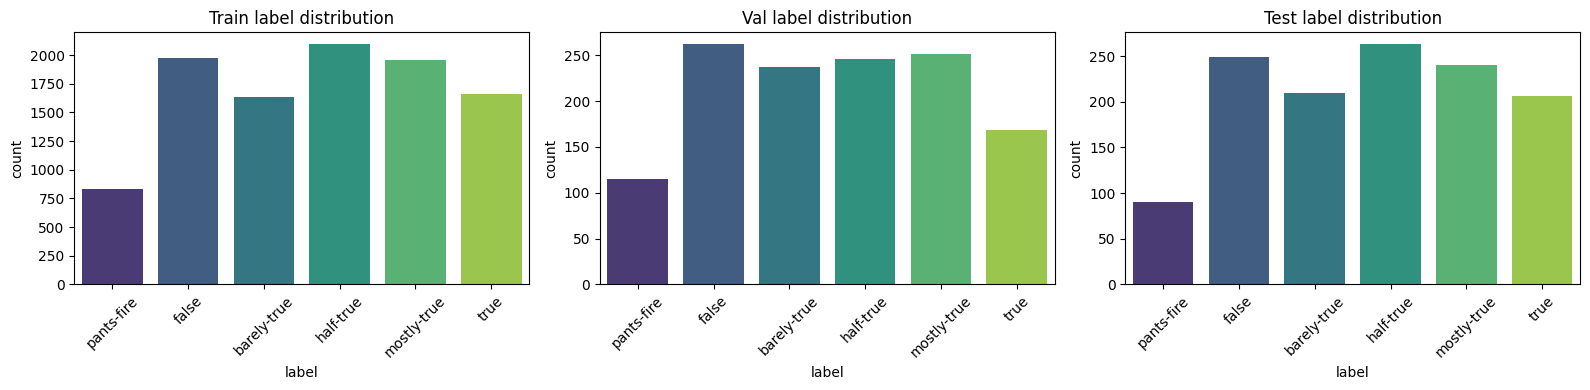


Train proportions (%):
label
half-true      20.63
false          19.46
mostly-true    19.24
true           16.38
barely-true    16.12
pants-fire      8.17
Name: proportion, dtype: float64

Val proportions (%):
label
false          20.47
mostly-true    19.61
half-true      19.22
barely-true    18.52
true           13.20
pants-fire      8.98
Name: proportion, dtype: float64

Test proportions (%):
label
half-true      20.91
false          19.79
mostly-true    19.08
barely-true    16.69
true           16.38
pants-fire      7.15
Name: proportion, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    sns.countplot(x='label', data=df, order=label_order, ax=ax, palette='viridis')
    ax.set_title(f'{name} label distribution')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'\n{name} proportions (%):')
    print((df['label'].value_counts(normalize=True) * 100).round(2))

In [12]:
print('Duplicate statements:', train_df['statement'].duplicated().sum())
print('Duplicate (statement, justification) pairs:', train_df.duplicated(subset=['statement', 'justification']).sum())

Duplicate statements: 17
Duplicate (statement, justification) pairs: 0


       statement_len  justification_len
count   10156.000000       10156.000000
mean       18.008862          71.415124
std         9.670134          43.581274
min         2.000000           4.000000
25%        12.000000          46.000000
50%        17.000000          66.000000
75%        22.000000          90.000000
max       467.000000        1103.000000


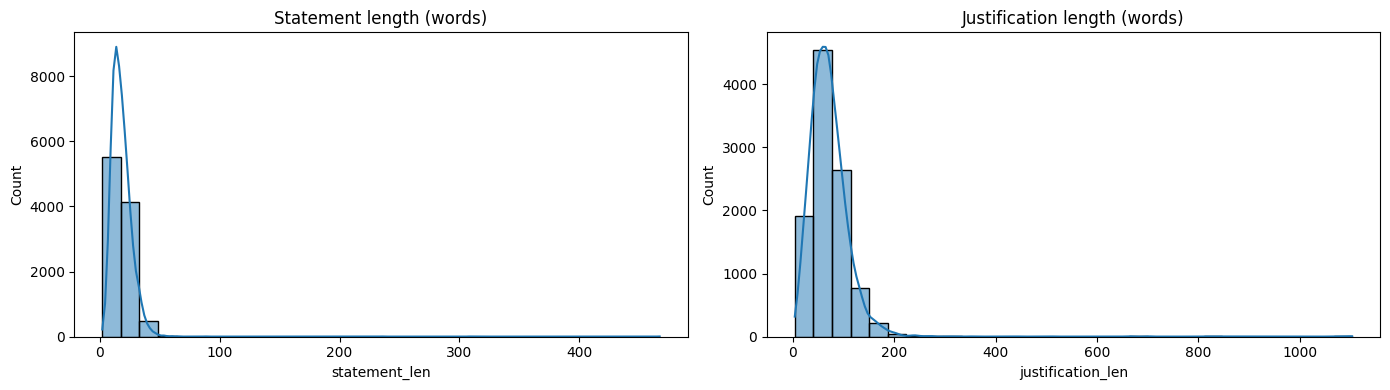

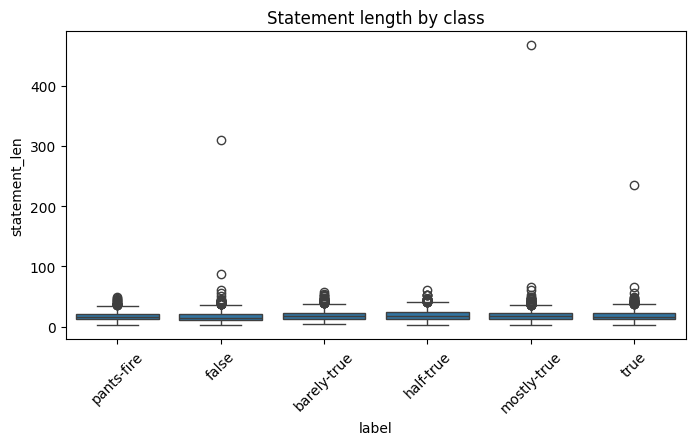

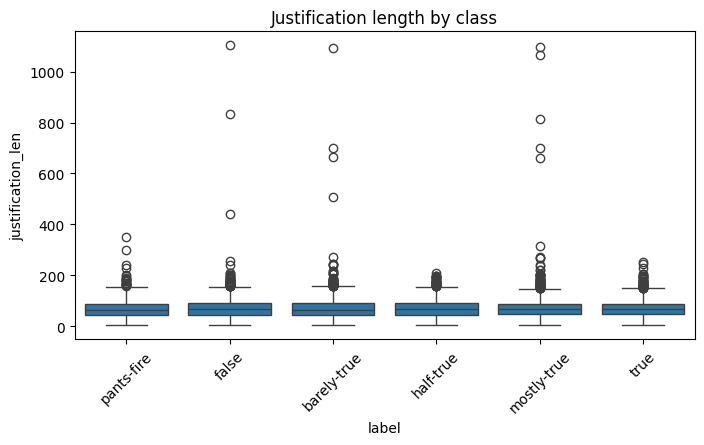

In [13]:
train_df['statement_len'] = train_df['statement'].str.split().str.len()
train_df['justification_len'] = train_df['justification'].str.split().str.len()

print(train_df[['statement_len', 'justification_len']].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train_df['statement_len'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Statement length (words)')
sns.histplot(train_df['justification_len'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Justification length (words)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='label', y='statement_len', data=train_df, order=label_order)
plt.xticks(rotation=45)
plt.title('Statement length by class')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x='label', y='justification_len', data=train_df, order=label_order)
plt.xticks(rotation=45)
plt.title('Justification length by class')
plt.show()

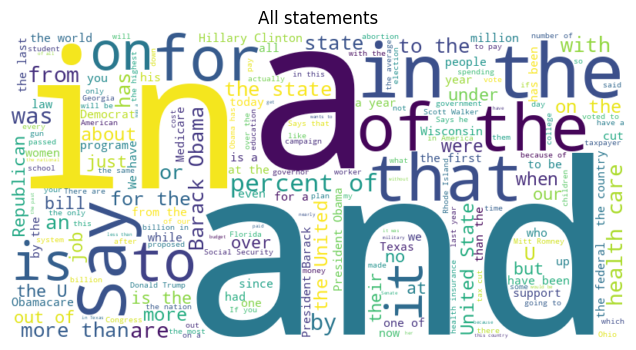

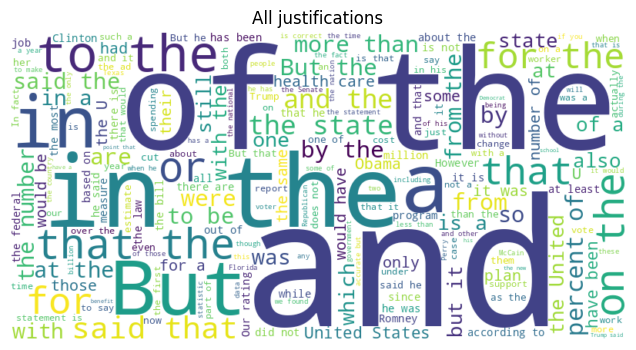

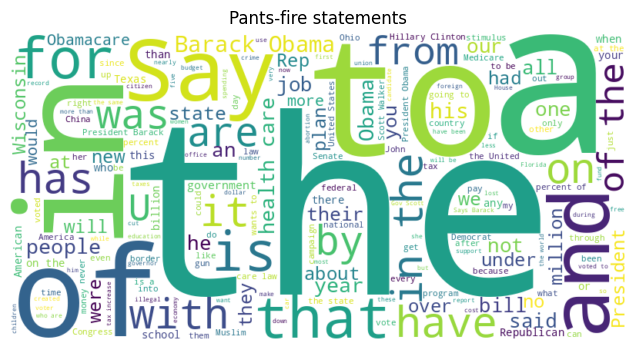

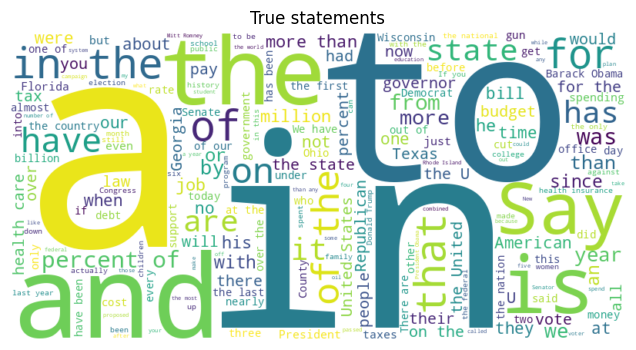

In [14]:
from wordcloud import WordCloud

def plot_wordcloud(text_series, title):
    text = ' '.join(text_series.dropna().astype(str))
    wc = WordCloud(width=800, height=400, background_color='white', stopwords='english').generate(text)
    plt.figure(figsize=(10, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_wordcloud(train_df['statement'], 'All statements')
plot_wordcloud(train_df['justification'], 'All justifications')

plot_wordcloud(train_df[train_df['label'] == 'pants-fire']['statement'], 'Pants-fire statements')
plot_wordcloud(train_df[train_df['label'] == 'true']['statement'], 'True statements')

# Data preprocessing

In [15]:
# Step 3a: Setup
# Downloading stopwords and keeping negation
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation/contrast words — critical for fact-checking semantics
NEGATION_WHITELIST = {  'no', 'not', 'nor', 'never', 'none', 'nobody', 'nothing', 'neither',
    'without', "n't", 'cannot', "isn't", "aren't", "wasn't", "weren't",
    "doesn't", "don't", "didn't", "won't", "wouldn't", "couldn't", "shouldn't"
}
stop_words = stop_words - NEGATION_WHITELIST

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [16]:
# Step 3b: Cleaning functions
# light cleaning for sequential models and aggressive cleaning for classical ml

def clean_light(text):
    """Light cleaning for DL models: preserves word order, stopwords, negation."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # URLs
    text = re.sub(r'[^a-z0-9\s\'\-]', ' ', text)            # keep apostrophes/hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_aggressive(text):
    """Aggressive cleaning for classical ML: stopword removal + lemmatization."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)                   # strip digits/punct entirely
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

In [17]:
# Step 3c: Apply to all splits

def preprocess_df(df):
    df = df.copy()
    for col in ['statement', 'justification']:
        df[f'{col}_light'] = df[col].apply(clean_light)
        df[f'{col}_agg']   = df[col].apply(clean_aggressive)

    # Combined text (statement + justification) for the second experiment
    df['combined_light'] = df['statement_light'] + ' ' + df['justification_light']
    df['combined_agg']   = df['statement_agg'] + ' ' + df['justification_agg']
    return df

train_df = preprocess_df(train_df)
val_df   = preprocess_df(val_df)
test_df  = preprocess_df(test_df)


train_df[['statement', 'statement_light', 'statement_agg']].head()

,statement,statement_light,statement_agg
0,Says the Annies List political group supports ...,says the annies list political group supports ...,say annies list political group support third ...
1,When did the decline of coal start? It started...,when did the decline of coal start it started ...,decline coal start started natural gas took st...
2,"Hillary Clinton agrees with John McCain ""by vo...",hillary clinton agrees with john mccain by vot...,hillary clinton agrees john mccain voting give...
3,Health care reform legislation is likely to ma...,health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
4,The economic turnaround started at the end of ...,the economic turnaround started at the end of ...,economic turnaround started end term


In [18]:
# Step 3d: Sanity check — vocab size before/after aggressive cleaning, and check for empty strings post-cleaning

from collections import Counter

raw_vocab = Counter(' '.join(train_df['statement'].str.lower()).split())
agg_vocab = Counter(' '.join(train_df['statement_agg']).split())
print(f'Raw vocab size: {len(raw_vocab)}')
print(f'Aggressively cleaned vocab size: {len(agg_vocab)}')

empty_after_clean = (train_df['statement_agg'].str.len() == 0).sum()
print(f'Rows with empty statement after aggressive cleaning: {empty_after_clean}')

Raw vocab size: 19979
Aggressively cleaned vocab size: 9965
Rows with empty statement after aggressive cleaning: 0


In [19]:
train_df.head()

,label,statement,justification,statement_len,justification_len,statement_light,statement_agg,justification_light,justification_agg,combined_light,combined_agg
0,false,Says the Annies List political group supports ...,That's a premise that he fails to back up. Ann...,11,40,says the annies list political group supports ...,say annies list political group support third ...,that's a premise that he fails to back up anni...,premise fails back annie list make no bone com...,says the annies list political group supports ...,say annies list political group support third ...
1,half-true,When did the decline of coal start? It started...,"Surovell said the decline of coal ""started whe...",24,104,when did the decline of coal start it started ...,decline coal start started natural gas took st...,surovell said the decline of coal started when...,surovell said decline coal started natural gas...,when did the decline of coal start it started ...,decline coal start started natural gas took st...
2,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",Obama said he would have voted against the ame...,19,74,hillary clinton agrees with john mccain by vot...,hillary clinton agrees john mccain voting give...,obama said he would have voted against the ame...,obama said would voted amendment present thoug...,hillary clinton agrees with john mccain by vot...,hillary clinton agrees john mccain voting give...
3,false,Health care reform legislation is likely to ma...,The release may have a point that Mikulskis co...,12,92,health care reform legislation is likely to ma...,health care reform legislation likely mandate ...,the release may have a point that mikulskis co...,release may point mikulskis comment could open...,health care reform legislation is likely to ma...,health care reform legislation likely mandate ...
4,half-true,The economic turnaround started at the end of ...,"Crist said that the economic ""turnaround start...",10,85,the economic turnaround started at the end of ...,economic turnaround started end term,crist said that the economic turnaround starte...,crist said economic turnaround started end ter...,the economic turnaround started at the end of ...,economic turnaround started end term crist sai...


# Tf-idf

In [20]:
# for random forest, logistic regression and naive bayes

from sklearn.feature_extraction.text import TfidfVectorizer

def build_tfidf(train_col, val_col, test_col, max_features=10000):
    vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2), min_df=2)
    X_train = vectorizer.fit_transform(train_col)
    X_val   = vectorizer.transform(val_col)
    X_test  = vectorizer.transform(test_col)
    return vectorizer, X_train, X_val, X_test

# Experiment 1: statement only
tfidf_stmt_vec, X_train_tfidf_stmt, X_val_tfidf_stmt, X_test_tfidf_stmt = build_tfidf(
    train_df['statement_agg'], val_df['statement_agg'], test_df['statement_agg']
)

# Experiment 2: statement + justification
tfidf_comb_vec, X_train_tfidf_comb, X_val_tfidf_comb, X_test_tfidf_comb = build_tfidf(
    train_df['combined_agg'], val_df['combined_agg'], test_df['combined_agg']
)

print('TF-IDF (statement only):', X_train_tfidf_stmt.shape)
print('TF-IDF (statement+justification):', X_train_tfidf_comb.shape)

TF-IDF (statement only): (10156, 10000)
TF-IDF (statement+justification): (10156, 10000)


In [21]:
!pip install gensim
import gensim
from gensim.models import Word2Vec

# Train on the light-cleaned combined text (train split only) so the vocabulary
# covers both statement-only and combined experiments consistently
w2v_corpus = train_df['combined_light'].apply(str.split).tolist()

w2v_model = Word2Vec(
    sentences=w2v_corpus,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,        # skip-gram; better for smaller datasets like this
    epochs=15,   # more training passes for better-quality vectors on a smaller corpus
    seed=42      # reproducibility
)

print('Word2Vec vocab size:', len(w2v_model.wv))
print(w2v_model.wv.most_similar('lie', topn=5))   # sanity check
print(w2v_model.wv.most_similar('tax', topn=5))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00
Word2Vec vocab size: 17283
[('listen', 0.6309255361557007), ('misquotes', 0.6175735592842102), ('pants-on-fire', 0.6166934967041016), ("conrad's", 0.6102535128593445), ('thatthe', 0.6089327931404114)]
[('hikes', 0.6976221799850464), ('taxes', 0.6830704808235168), ('income-tax', 0.6520766019821167), ('breaks', 0.6416283845901489), ('taxable', 0.6328261494636536)]


In [22]:
import numpy as np

def document_vector(text, model, dim=100):
    words = [w for w in text.split() if w in model.wv]
    if not words:
        return np.zeros(dim)
    return np.mean([model.wv[w] for w in words], axis=0)

# Experiment 1: statement only
X_train_w2v_stmt = np.array([document_vector(t, w2v_model) for t in train_df['statement_light']])
X_val_w2v_stmt   = np.array([document_vector(t, w2v_model) for t in val_df['statement_light']])
X_test_w2v_stmt  = np.array([document_vector(t, w2v_model) for t in test_df['statement_light']])

# Experiment 2: statement + justification
X_train_w2v_comb = np.array([document_vector(t, w2v_model) for t in train_df['combined_light']])
X_val_w2v_comb   = np.array([document_vector(t, w2v_model) for t in val_df['combined_light']])
X_test_w2v_comb  = np.array([document_vector(t, w2v_model) for t in test_df['combined_light']])

print('Word2Vec doc-vector shape (statement only):', X_train_w2v_stmt.shape)
print('Word2Vec doc-vector shape (combined):', X_train_w2v_comb.shape)

Word2Vec doc-vector shape (statement only): (10156, 100)
Word2Vec doc-vector shape (combined): (10156, 100)


# Label encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']

label_encoder = LabelEncoder()
label_encoder.fit(label_order)  # fit on the fixed order, not just train_df['label'], so encoding is consistent

print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

y_train = label_encoder.transform(train_df['label'])
y_val   = label_encoder.transform(val_df['label'])
y_test  = label_encoder.transform(test_df['label'])

print(y_train[:10])
print('Train label counts:', np.bincount(y_train))

{np.str_('barely-true'): np.int64(0), np.str_('false'): np.int64(1), np.str_('half-true'): np.int64(2), np.str_('mostly-true'): np.int64(3), np.str_('pants-fire'): np.int64(4), np.str_('true'): np.int64(5)}
[1 2 3 1 2 5 0 2 2 3]
Train label counts: [1637 1976 2095 1954  830 1664]


One hot vector

In [24]:
from tensorflow.keras.utils import to_categorical

num_classes = len(label_order)

y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

print(y_train_cat.shape, y_val_cat.shape, y_test_cat.shape)

(10156, 6) (1280, 6) (1258, 6)


In [25]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_arr))
print(class_weights)

{0: np.float64(1.0340052942374263), 1: np.float64(0.856612685560054), 2: np.float64(0.8079554494828958), 3: np.float64(0.8662572500852951), 4: np.float64(2.0393574297188755), 5: np.float64(1.017227564102564)}


# ML models (Random forest, Logistic regression, Naive Bayes)

In [26]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# This will hold ALL model results across the whole project — keep reusing it
results_table = []       # final test-set results: one row per (model, experiment, representation)
tuning_log = []          # every hyperparameter run: one row per (model, experiment, representation, config)

def evaluate_on_test(model, X_test, y_test, model_name, experiment):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')
    print(f'\n=== {model_name} | {experiment} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))
    cm = confusion_matrix(y_test, preds)
    return acc, f1_macro, f1_weighted, cm, preds

def plot_confusion(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_order, yticklabels=label_order)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(title)
    plt.xticks(rotation=45); plt.yticks(rotation=45)
    plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2},
    {'n_estimators': 300, 'max_depth': 30,   'min_samples_split': 5},
    {'n_estimators': 500, 'max_depth': 50,   'min_samples_split': 10},
]

experiments_tfidf = {
    'statement_only': (X_train_tfidf_stmt, X_val_tfidf_stmt, X_test_tfidf_stmt),
    'combined':       (X_train_tfidf_comb, X_val_tfidf_comb, X_test_tfidf_comb),
}

rf_best_tfidf = {}  # best model per experiment (TF-IDF)

for exp_name, (X_tr, X_val, X_te) in experiments_tfidf.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    for cfg in rf_configs:
        clf = RandomForestClassifier(**cfg, class_weight=class_weights, random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_train)
        val_preds = clf.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model':'RandomForest','experiment':exp_name,'representation':'tfidf',**cfg,'val_macro_f1':val_f1})
        print(f'RF (TF-IDF) | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, clf, cfg
    rf_best_tfidf[exp_name] = best_model
    print(f'--> Best RF (TF-IDF) config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

RF (TF-IDF) | statement_only | {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | val macro-F1: 0.2513
RF (TF-IDF) | statement_only | {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5} | val macro-F1: 0.2456
RF (TF-IDF) | statement_only | {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} | val macro-F1: 0.2563
--> Best RF (TF-IDF) config for statement_only: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} (val macro-F1: 0.2563)

RF (TF-IDF) | combined | {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | val macro-F1: 0.1882
RF (TF-IDF) | combined | {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5} | val macro-F1: 0.2201
RF (TF-IDF) | combined | {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} | val macro-F1: 0.2204
--> Best RF (TF-IDF) config for combined: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} (val macro-F1: 0.2204)



In [28]:
experiments_w2v = {
    'statement_only': (X_train_w2v_stmt, X_val_w2v_stmt, X_test_w2v_stmt),
    'combined':       (X_train_w2v_comb, X_val_w2v_comb, X_test_w2v_comb),
}

rf_best_w2v = {}  # best model per experiment (Word2Vec)

for exp_name, (X_tr, X_val, X_te) in experiments_w2v.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    for cfg in rf_configs:
        clf = RandomForestClassifier(**cfg, class_weight=class_weights, random_state=42, n_jobs=-1)
        clf.fit(X_tr, y_train)
        val_preds = clf.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model':'RandomForest','experiment':exp_name,'representation':'word2vec',**cfg,'val_macro_f1':val_f1})
        print(f'RF (Word2Vec) | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, clf, cfg
    rf_best_w2v[exp_name] = best_model
    print(f'--> Best RF (Word2Vec) config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

RF (Word2Vec) | statement_only | {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | val macro-F1: 0.2212
RF (Word2Vec) | statement_only | {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5} | val macro-F1: 0.2113
RF (Word2Vec) | statement_only | {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} | val macro-F1: 0.2494
--> Best RF (Word2Vec) config for statement_only: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} (val macro-F1: 0.2494)

RF (Word2Vec) | combined | {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2} | val macro-F1: 0.1720
RF (Word2Vec) | combined | {'n_estimators': 300, 'max_depth': 30, 'min_samples_split': 5} | val macro-F1: 0.1836
RF (Word2Vec) | combined | {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} | val macro-F1: 0.1960
--> Best RF (Word2Vec) config for combined: {'n_estimators': 500, 'max_depth': 50, 'min_samples_split': 10} (val macro-F1: 0.1960)



In [29]:
from sklearn.linear_model import LogisticRegression

lr_configs = [
    {'C': 0.1, 'solver': 'liblinear'},
    {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000},
    {'C': 10.0, 'solver': 'lbfgs', 'max_iter': 1000},
]

lr_best_tfidf = {}

for exp_name, (X_tr, X_val, X_te) in experiments_tfidf.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    for cfg in lr_configs:
        clf = LogisticRegression(**cfg, class_weight=class_weights, random_state=42)
        clf.fit(X_tr, y_train)
        val_preds = clf.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model':'LogisticRegression','experiment':exp_name,'representation':'tfidf',**cfg,'val_macro_f1':val_f1})
        print(f'LR (TF-IDF) | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, clf, cfg
    lr_best_tfidf[exp_name] = best_model
    print(f'--> Best LR (TF-IDF) config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

LR (TF-IDF) | statement_only | {'C': 0.1, 'solver': 'liblinear'} | val macro-F1: 0.2407
LR (TF-IDF) | statement_only | {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2489
LR (TF-IDF) | statement_only | {'C': 10.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2459
--> Best LR (TF-IDF) config for statement_only: {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000} (val macro-F1: 0.2489)

LR (TF-IDF) | combined | {'C': 0.1, 'solver': 'liblinear'} | val macro-F1: 0.2414
LR (TF-IDF) | combined | {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2313
LR (TF-IDF) | combined | {'C': 10.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2110
--> Best LR (TF-IDF) config for combined: {'C': 0.1, 'solver': 'liblinear'} (val macro-F1: 0.2414)



In [30]:
lr_best_w2v = {}

for exp_name, (X_tr, X_val, X_te) in experiments_w2v.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    for cfg in lr_configs:
        clf = LogisticRegression(**cfg, class_weight=class_weights, random_state=42)
        clf.fit(X_tr, y_train)
        val_preds = clf.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model':'LogisticRegression','experiment':exp_name,'representation':'word2vec',**cfg,'val_macro_f1':val_f1})
        print(f'LR (Word2Vec) | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, clf, cfg
    lr_best_w2v[exp_name] = best_model
    print(f'--> Best LR (Word2Vec) config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

LR (Word2Vec) | statement_only | {'C': 0.1, 'solver': 'liblinear'} | val macro-F1: 0.2324
LR (Word2Vec) | statement_only | {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2151
LR (Word2Vec) | statement_only | {'C': 10.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2146
--> Best LR (Word2Vec) config for statement_only: {'C': 0.1, 'solver': 'liblinear'} (val macro-F1: 0.2324)

LR (Word2Vec) | combined | {'C': 0.1, 'solver': 'liblinear'} | val macro-F1: 0.2606
LR (Word2Vec) | combined | {'C': 1.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2414
LR (Word2Vec) | combined | {'C': 10.0, 'solver': 'lbfgs', 'max_iter': 1000} | val macro-F1: 0.2280
--> Best LR (Word2Vec) config for combined: {'C': 0.1, 'solver': 'liblinear'} (val macro-F1: 0.2606)



In [31]:
from sklearn.naive_bayes import MultinomialNB

nb_configs = [
    {'alpha': 0.1},
    {'alpha': 0.5},
    {'alpha': 1.0},
]

nb_best = {}

for exp_name, (X_tr, X_val, X_te) in experiments_tfidf.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    for cfg in nb_configs:
        clf = MultinomialNB(**cfg)
        clf.fit(X_tr, y_train)
        val_preds = clf.predict(X_val)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model':'NaiveBayes','experiment':exp_name,'representation':'tfidf',**cfg,'val_macro_f1':val_f1})
        print(f'NB | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')
        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, clf, cfg
    nb_best[exp_name] = best_model
    print(f'--> Best NB config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

NB | statement_only | {'alpha': 0.1} | val macro-F1: 0.2263
NB | statement_only | {'alpha': 0.5} | val macro-F1: 0.2149
NB | statement_only | {'alpha': 1.0} | val macro-F1: 0.1993
--> Best NB config for statement_only: {'alpha': 0.1} (val macro-F1: 0.2263)

NB | combined | {'alpha': 0.1} | val macro-F1: 0.2120
NB | combined | {'alpha': 0.5} | val macro-F1: 0.1993
NB | combined | {'alpha': 1.0} | val macro-F1: 0.1780
--> Best NB config for combined: {'alpha': 0.1} (val macro-F1: 0.2120)




=== RandomForest | statement_only | TEST SET ===
Accuracy: 0.2528 | Macro-F1: 0.2474 | Weighted-F1: 0.2509
              precision    recall  f1-score   support

  pants-fire       0.26      0.26      0.26       210
       false       0.25      0.25      0.25       249
 barely-true       0.27      0.17      0.21       263
   half-true       0.27      0.32      0.29       240
 mostly-true       0.17      0.24      0.20        90
        true       0.26      0.28      0.27       206

    accuracy                           0.25      1258
   macro avg       0.25      0.25      0.25      1258
weighted avg       0.26      0.25      0.25      1258



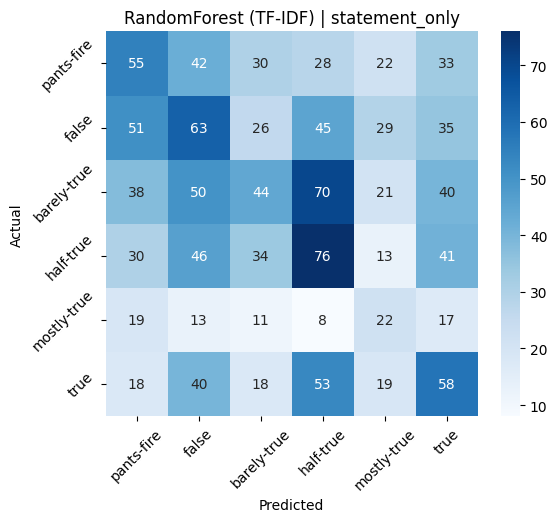


=== RandomForest | combined | TEST SET ===
Accuracy: 0.2210 | Macro-F1: 0.2021 | Weighted-F1: 0.2187
              precision    recall  f1-score   support

  pants-fire       0.19      0.16      0.17       210
       false       0.18      0.19      0.19       249
 barely-true       0.25      0.27      0.26       263
   half-true       0.25      0.28      0.26       240
 mostly-true       0.07      0.06      0.06        90
        true       0.28      0.26      0.27       206

    accuracy                           0.22      1258
   macro avg       0.20      0.20      0.20      1258
weighted avg       0.22      0.22      0.22      1258



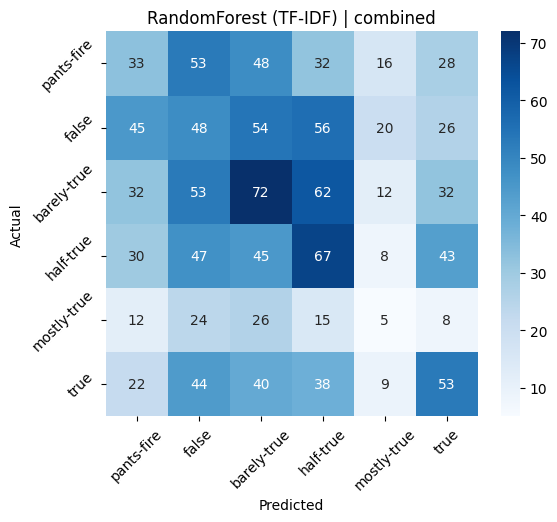


=== LogisticRegression | statement_only | TEST SET ===
Accuracy: 0.2409 | Macro-F1: 0.2382 | Weighted-F1: 0.2418
              precision    recall  f1-score   support

  pants-fire       0.22      0.22      0.22       210
       false       0.27      0.21      0.24       249
 barely-true       0.29      0.24      0.26       263
   half-true       0.24      0.23      0.23       240
 mostly-true       0.16      0.30      0.21        90
        true       0.25      0.29      0.27       206

    accuracy                           0.24      1258
   macro avg       0.24      0.25      0.24      1258
weighted avg       0.25      0.24      0.24      1258



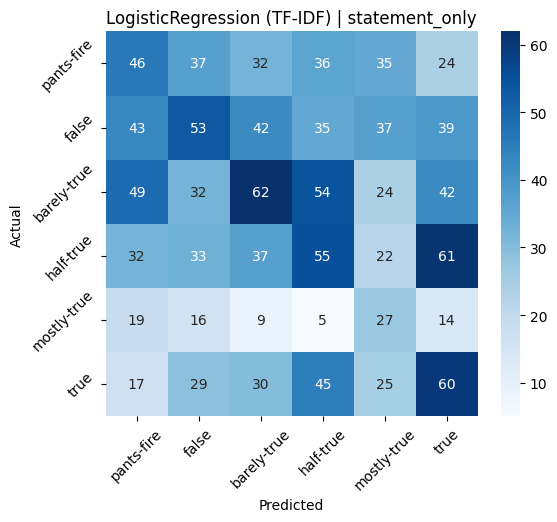


=== LogisticRegression | combined | TEST SET ===
Accuracy: 0.2186 | Macro-F1: 0.2028 | Weighted-F1: 0.2131
              precision    recall  f1-score   support

  pants-fire       0.22      0.13      0.17       210
       false       0.21      0.26      0.24       249
 barely-true       0.25      0.32      0.28       263
   half-true       0.20      0.22      0.21       240
 mostly-true       0.20      0.11      0.14        90
        true       0.19      0.17      0.18       206

    accuracy                           0.22      1258
   macro avg       0.21      0.20      0.20      1258
weighted avg       0.22      0.22      0.21      1258



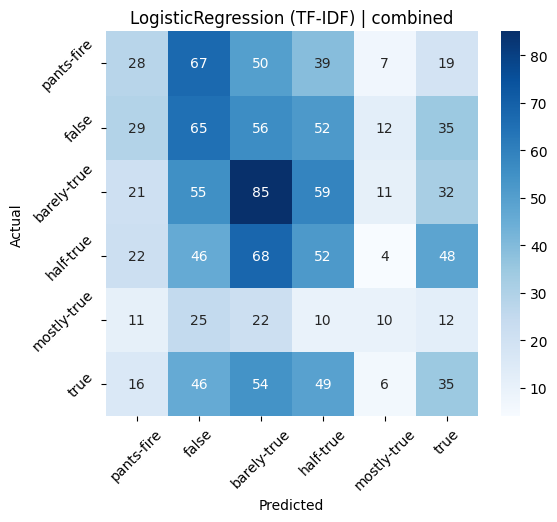


=== NaiveBayes | statement_only | TEST SET ===
Accuracy: 0.2432 | Macro-F1: 0.2171 | Weighted-F1: 0.2375
              precision    recall  f1-score   support

  pants-fire       0.26      0.21      0.24       210
       false       0.24      0.26      0.25       249
 barely-true       0.28      0.32      0.30       263
   half-true       0.25      0.29      0.27       240
 mostly-true       0.12      0.04      0.06        90
        true       0.19      0.18      0.18       206

    accuracy                           0.24      1258
   macro avg       0.22      0.22      0.22      1258
weighted avg       0.24      0.24      0.24      1258



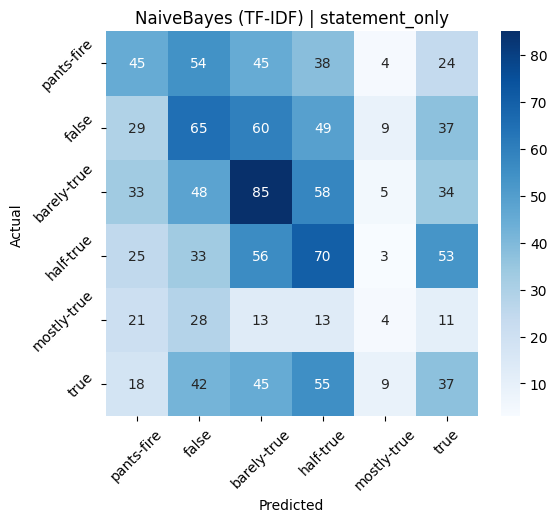


=== NaiveBayes | combined | TEST SET ===
Accuracy: 0.2361 | Macro-F1: 0.2121 | Weighted-F1: 0.2278
              precision    recall  f1-score   support

  pants-fire       0.27      0.17      0.21       210
       false       0.24      0.29      0.26       249
 barely-true       0.24      0.35      0.28       263
   half-true       0.21      0.23      0.22       240
 mostly-true       0.45      0.06      0.10        90
        true       0.21      0.18      0.20       206

    accuracy                           0.24      1258
   macro avg       0.27      0.21      0.21      1258
weighted avg       0.25      0.24      0.23      1258



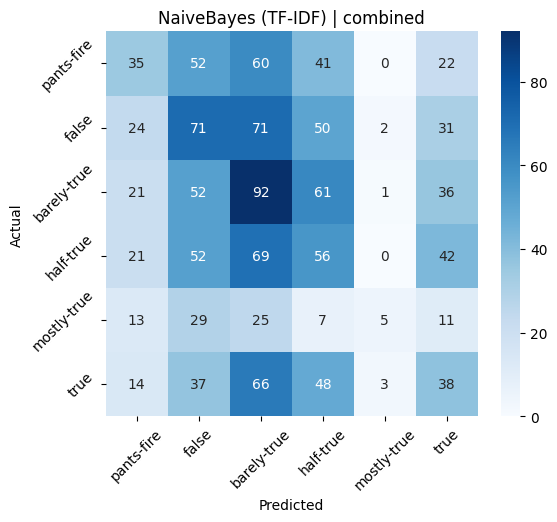

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780


In [32]:
for model_name, best_dict in [('RandomForest', rf_best_tfidf), ('LogisticRegression', lr_best_tfidf), ('NaiveBayes', nb_best)]:
    for exp_name, (X_tr, X_val, X_te) in experiments_tfidf.items():
        model = best_dict[exp_name]
        acc, f1_macro, f1_weighted, cm, preds = evaluate_on_test(model, X_te, y_test, model_name, exp_name)
        plot_confusion(cm, f'{model_name} (TF-IDF) | {exp_name}')
        results_table.append({
            'model': model_name, 'experiment': exp_name, 'representation': 'tfidf',
            'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
        })

pd.DataFrame(results_table)


=== RandomForest | statement_only | TEST SET ===
Accuracy: 0.2782 | Macro-F1: 0.2402 | Weighted-F1: 0.2608
              precision    recall  f1-score   support

  pants-fire       0.28      0.19      0.23       210
       false       0.28      0.42      0.34       249
 barely-true       0.28      0.36      0.31       263
   half-true       0.29      0.35      0.32       240
 mostly-true       0.35      0.07      0.11        90
        true       0.21      0.10      0.13       206

    accuracy                           0.28      1258
   macro avg       0.28      0.25      0.24      1258
weighted avg       0.28      0.28      0.26      1258



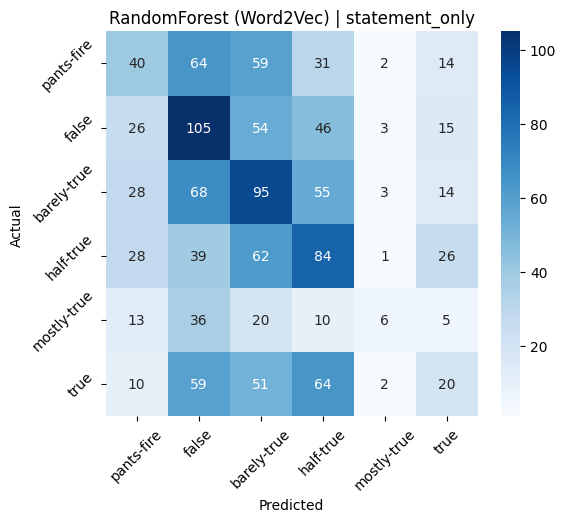


=== RandomForest | combined | TEST SET ===
Accuracy: 0.2432 | Macro-F1: 0.1937 | Weighted-F1: 0.2208
              precision    recall  f1-score   support

  pants-fire       0.21      0.10      0.13       210
       false       0.22      0.28      0.25       249
 barely-true       0.26      0.47      0.33       263
   half-true       0.23      0.25      0.24       240
 mostly-true       0.00      0.00      0.00        90
        true       0.28      0.17      0.21       206

    accuracy                           0.24      1258
   macro avg       0.20      0.21      0.19      1258
weighted avg       0.23      0.24      0.22      1258



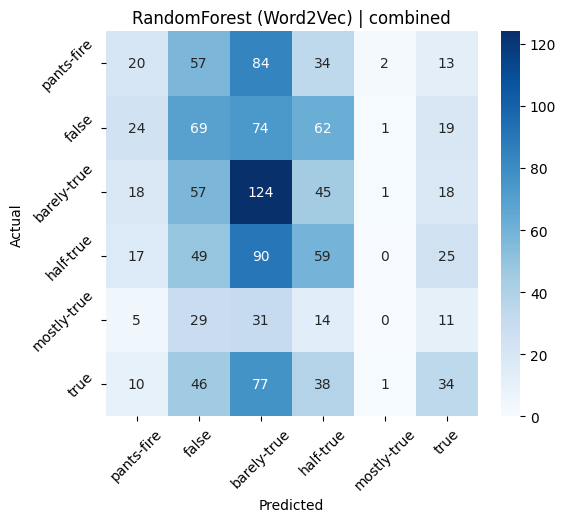


=== LogisticRegression | statement_only | TEST SET ===
Accuracy: 0.2361 | Macro-F1: 0.2303 | Weighted-F1: 0.2360
              precision    recall  f1-score   support

  pants-fire       0.27      0.22      0.24       210
       false       0.22      0.22      0.22       249
 barely-true       0.25      0.17      0.20       263
   half-true       0.28      0.33      0.30       240
 mostly-true       0.13      0.26      0.17        90
        true       0.26      0.23      0.24       206

    accuracy                           0.24      1258
   macro avg       0.23      0.24      0.23      1258
weighted avg       0.24      0.24      0.24      1258



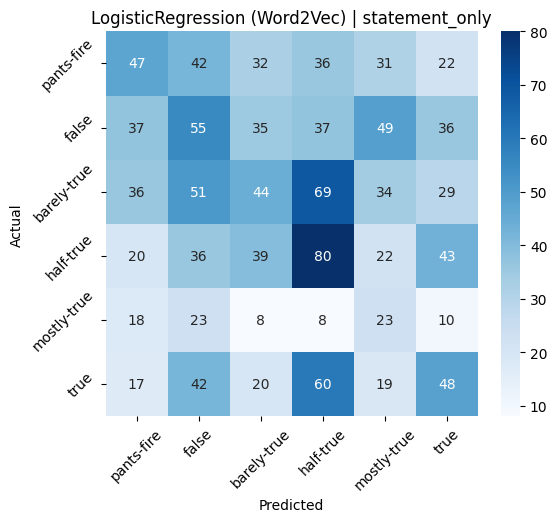


=== LogisticRegression | combined | TEST SET ===
Accuracy: 0.2297 | Macro-F1: 0.2174 | Weighted-F1: 0.2308
              precision    recall  f1-score   support

  pants-fire       0.20      0.17      0.18       210
       false       0.20      0.22      0.21       249
 barely-true       0.26      0.26      0.26       263
   half-true       0.28      0.28      0.28       240
 mostly-true       0.10      0.12      0.11        90
        true       0.28      0.25      0.26       206

    accuracy                           0.23      1258
   macro avg       0.22      0.22      0.22      1258
weighted avg       0.23      0.23      0.23      1258



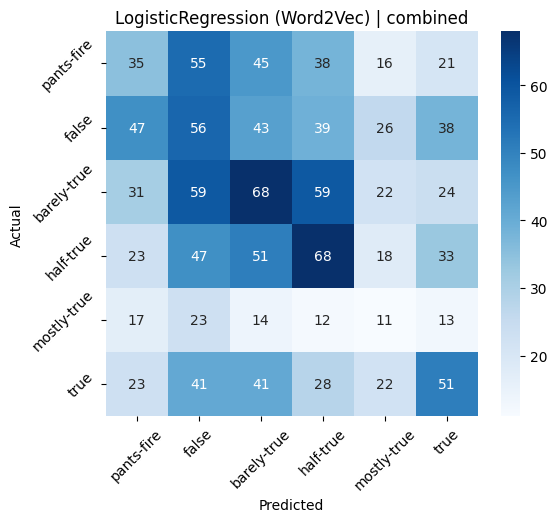

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [33]:
for model_name, best_dict in [('RandomForest', rf_best_w2v), ('LogisticRegression', lr_best_w2v)]:
    for exp_name, (X_tr, X_val, X_te) in experiments_w2v.items():
        model = best_dict[exp_name]
        acc, f1_macro, f1_weighted, cm, preds = evaluate_on_test(model, X_te, y_test, model_name, exp_name)
        plot_confusion(cm, f'{model_name} (Word2Vec) | {exp_name}')
        results_table.append({
            'model': model_name, 'experiment': exp_name, 'representation': 'word2vec',
            'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
        })

pd.DataFrame(results_table)

In [34]:
pd.DataFrame(results_table)

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


# NN models

Simple rnn

In [35]:
# keras tokenizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

def build_sequences(train_col, val_col, test_col, max_words=15000, max_len=None):
    tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_col)

    train_seq = tokenizer.texts_to_sequences(train_col)
    val_seq   = tokenizer.texts_to_sequences(val_col)
    test_seq  = tokenizer.texts_to_sequences(test_col)

    if max_len is None:
        max_len = int(np.percentile([len(s) for s in train_seq], 95))  # cover 95% of samples

    X_train = pad_sequences(train_seq, maxlen=max_len, padding='post', truncating='post')
    X_val   = pad_sequences(val_seq, maxlen=max_len, padding='post', truncating='post')
    X_test  = pad_sequences(test_seq, maxlen=max_len, padding='post', truncating='post')

    return tokenizer, X_train, X_val, X_test, max_len

import numpy as np

tok_stmt, X_train_seq_stmt, X_val_seq_stmt, X_test_seq_stmt, maxlen_stmt = build_sequences(
    train_df['statement_light'], val_df['statement_light'], test_df['statement_light']
)

tok_comb, X_train_seq_comb, X_val_seq_comb, X_test_seq_comb, maxlen_comb = build_sequences(
    train_df['combined_light'], val_df['combined_light'], test_df['combined_light']
)

print('Statement-only: vocab', len(tok_stmt.word_index), '| max_len', maxlen_stmt)
print('Combined: vocab', len(tok_comb.word_index), '| max_len', maxlen_comb)

Statement-only: vocab 12364 | max_len 33
Combined: vocab 25885 | max_len 154


In [36]:
# embedding matrix

def build_embedding_matrix(tokenizer, w2v_model, embedding_dim=100, max_words=15000):
    vocab_size = min(max_words, len(tokenizer.word_index) + 1)
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    hits, misses = 0, 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        if word in w2v_model.wv:
            embedding_matrix[idx] = w2v_model.wv[word]
            hits += 1
        else:
            misses += 1
    print(f'Embedding coverage: {hits} hits, {misses} misses ({hits/(hits+misses)*100:.1f}% covered)')
    return embedding_matrix

embedding_matrix_stmt = build_embedding_matrix(tok_stmt, w2v_model)
embedding_matrix_comb = build_embedding_matrix(tok_comb, w2v_model)

Embedding coverage: 10860 hits, 1504 misses (87.8% covered)
Embedding coverage: 14790 hits, 209 misses (98.6% covered)


In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

def build_rnn_model(layer_type, bidirectional, vocab_size, embedding_dim, embedding_matrix,
                     max_len, units, dropout, learning_rate):
    layer_cls = {'SimpleRNN': SimpleRNN}[layer_type]
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                         weights=[embedding_matrix], input_length=max_len, trainable=False))
    rnn_layer = layer_cls(units, dropout=dropout)
    model.add(Bidirectional(rnn_layer) if bidirectional else rnn_layer)
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

rnn_configs = [
    {'units': 64,  'dropout': 0.2, 'learning_rate': 1e-3},
    {'units': 128, 'dropout': 0.3, 'learning_rate': 1e-3},
    {'units': 128, 'dropout': 0.4, 'learning_rate': 5e-4},
]

experiments_seq = {
    'statement_only': (X_train_seq_stmt, X_val_seq_stmt, X_test_seq_stmt, embedding_matrix_stmt, maxlen_stmt),
    'combined':       (X_train_seq_comb, X_val_seq_comb, X_test_seq_comb, embedding_matrix_comb, maxlen_comb),
}

In [38]:
simplernn_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('SimpleRNN', False, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'SimpleRNN', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'SimpleRNN | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    simplernn_best[exp_name] = best_model
    print(f'--> Best SimpleRNN config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.1618


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.0805


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

SimpleRNN | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.1024


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.0785


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


SimpleRNN | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.1279
--> Best SimpleRNN config for combined: {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} (val macro-F1: 0.1279)




=== SimpleRNN | statement_only | TEST SET ===
Accuracy: 0.1439 | Macro-F1: 0.1329 | Weighted-F1: 0.1300
              precision    recall  f1-score   support

  pants-fire       0.15      0.04      0.06       210
       false       0.25      0.04      0.07       249
 barely-true       0.19      0.08      0.11       263
   half-true       0.23      0.17      0.20       240
 mostly-true       0.08      0.57      0.14        90
        true       0.20      0.24      0.22       206

    accuracy                           0.14      1258
   macro avg       0.18      0.19      0.13      1258
weighted avg       0.19      0.14      0.13      1258



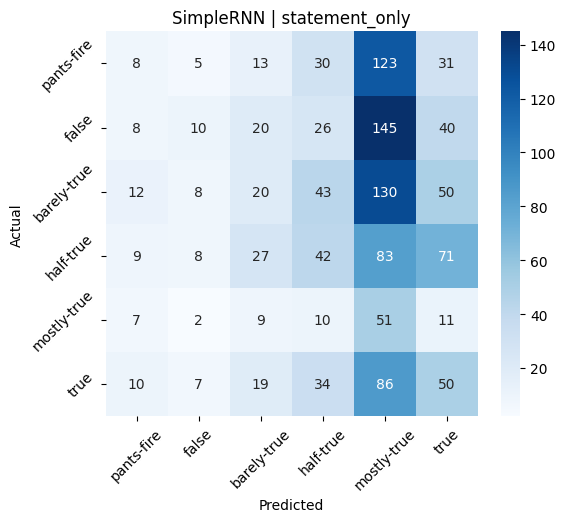


=== SimpleRNN | combined | TEST SET ===
Accuracy: 0.1717 | Macro-F1: 0.1185 | Weighted-F1: 0.1308
              precision    recall  f1-score   support

  pants-fire       0.19      0.03      0.06       210
       false       0.20      0.06      0.10       249
 barely-true       0.23      0.06      0.09       263
   half-true       0.18      0.44      0.25       240
 mostly-true       0.00      0.00      0.00        90
        true       0.15      0.35      0.21       206

    accuracy                           0.17      1258
   macro avg       0.16      0.16      0.12      1258
weighted avg       0.18      0.17      0.13      1258



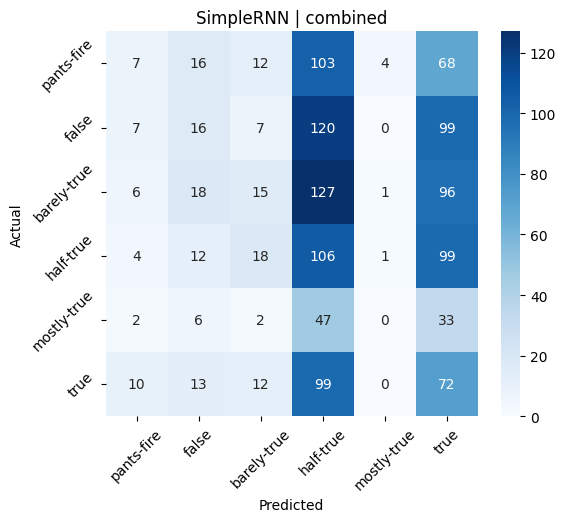

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [39]:
for exp_name, model in simplernn_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== SimpleRNN | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'SimpleRNN | {exp_name}')

    results_table.append({
        'model': 'SimpleRNN', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

In [40]:
bi_simplernn_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('SimpleRNN', True, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'BiSimpleRNN', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'BiSimpleRNN | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    bi_simplernn_best[exp_name] = best_model
    print(f'--> Best BiSimpleRNN config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiSimpleRNN | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.1960


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiSimpleRNN | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1744


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

BiSimpleRNN | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2077


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiSimpleRNN | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1584


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiSimpleRNN | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.1411
--> Best BiSimpleRNN config for combined: {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} (val macro-F1: 0.2077)




=== BiSimpleRNN | statement_only | TEST SET ===
Accuracy: 0.2035 | Macro-F1: 0.1916 | Weighted-F1: 0.1927
              precision    recall  f1-score   support

  pants-fire       0.20      0.19      0.19       210
       false       0.28      0.22      0.24       249
 barely-true       0.20      0.03      0.05       263
   half-true       0.26      0.26      0.26       240
 mostly-true       0.10      0.30      0.15        90
        true       0.20      0.32      0.25       206

    accuracy                           0.20      1258
   macro avg       0.21      0.22      0.19      1258
weighted avg       0.22      0.20      0.19      1258



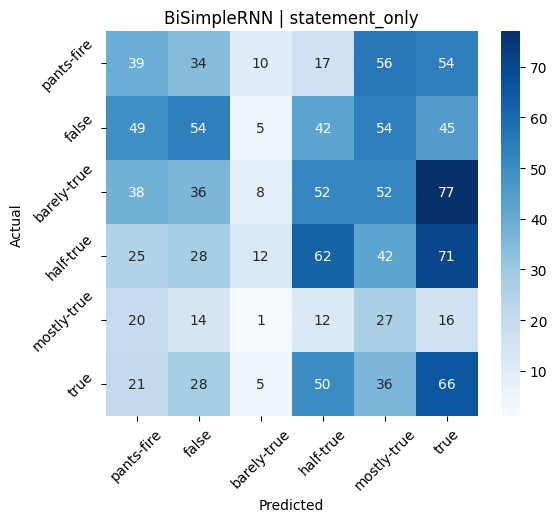


=== BiSimpleRNN | combined | TEST SET ===
Accuracy: 0.2067 | Macro-F1: 0.1915 | Weighted-F1: 0.1932
              precision    recall  f1-score   support

  pants-fire       0.18      0.10      0.12       210
       false       0.25      0.23      0.24       249
 barely-true       0.25      0.06      0.10       263
   half-true       0.24      0.38      0.29       240
 mostly-true       0.12      0.33      0.17        90
        true       0.21      0.22      0.21       206

    accuracy                           0.21      1258
   macro avg       0.21      0.22      0.19      1258
weighted avg       0.22      0.21      0.19      1258



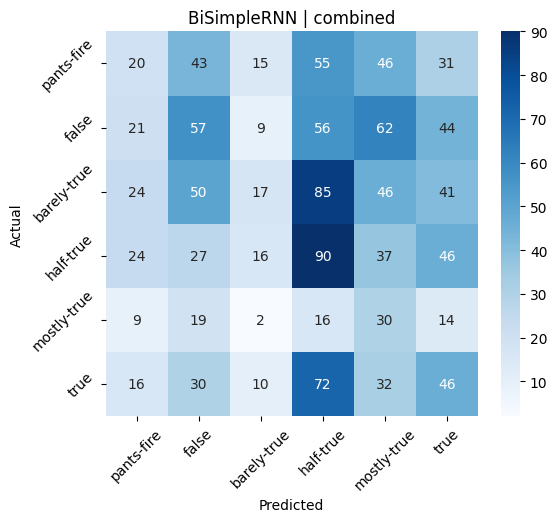

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [41]:
for exp_name, model in bi_simplernn_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== BiSimpleRNN | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'BiSimpleRNN | {exp_name}')

    results_table.append({
        'model': 'BiSimpleRNN', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

GRU

In [42]:
from tensorflow.keras.layers import GRU, LSTM

def build_rnn_model(layer_type, bidirectional, vocab_size, embedding_dim, embedding_matrix,
                     max_len, units, dropout, learning_rate):
    layer_cls = {'SimpleRNN': SimpleRNN, 'GRU': GRU, 'LSTM': LSTM}[layer_type]
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                         weights=[embedding_matrix], input_length=max_len, trainable=False))
    rnn_layer = layer_cls(units, dropout=dropout)
    model.add(Bidirectional(rnn_layer) if bidirectional else rnn_layer)
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [43]:
gru_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('GRU', False, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'GRU', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'GRU | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    gru_best[exp_name] = best_model
    print(f'--> Best GRU config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2253


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1468


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

GRU | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.0682


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.0664


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.0719
--> Best GRU config for combined: {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} (val macro-F1: 0.0719)




=== GRU | statement_only | TEST SET ===
Accuracy: 0.2345 | Macro-F1: 0.2126 | Weighted-F1: 0.2175
              precision    recall  f1-score   support

  pants-fire       0.25      0.13      0.17       210
       false       0.31      0.26      0.28       249
 barely-true       0.22      0.08      0.12       263
   half-true       0.21      0.50      0.29       240
 mostly-true       0.15      0.17      0.16        90
        true       0.28      0.23      0.25       206

    accuracy                           0.23      1258
   macro avg       0.24      0.23      0.21      1258
weighted avg       0.25      0.23      0.22      1258



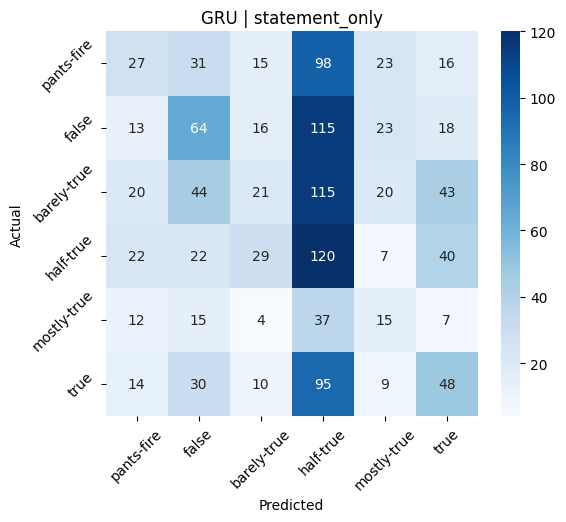


=== GRU | combined | TEST SET ===
Accuracy: 0.2051 | Macro-F1: 0.0762 | Weighted-F1: 0.0913
              precision    recall  f1-score   support

  pants-fire       0.33      0.04      0.08       210
       false       0.17      0.00      0.01       249
 barely-true       0.20      0.92      0.33       263
   half-true       0.12      0.02      0.03       240
 mostly-true       0.00      0.00      0.00        90
        true       0.50      0.00      0.01       206

    accuracy                           0.21      1258
   macro avg       0.22      0.17      0.08      1258
weighted avg       0.24      0.21      0.09      1258



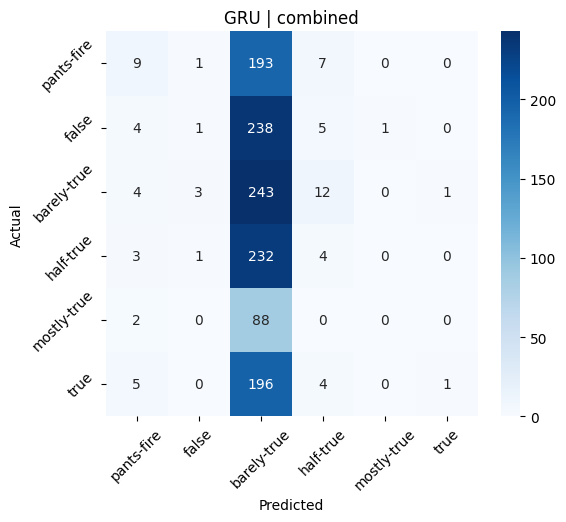

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [44]:
for exp_name, model in gru_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== GRU | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'GRU | {exp_name}')

    results_table.append({
        'model': 'GRU', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

In [45]:
bi_gru_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('GRU', True, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'BiGRU', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'BiGRU | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    bi_gru_best[exp_name] = best_model
    print(f'--> Best BiGRU config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiGRU | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2164


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiGRU | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1902


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

BiGRU | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2276


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiGRU | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.2195


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiGRU | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.2140
--> Best BiGRU config for combined: {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} (val macro-F1: 0.2276)




=== BiGRU | statement_only | TEST SET ===
Accuracy: 0.2417 | Macro-F1: 0.2314 | Weighted-F1: 0.2364
              precision    recall  f1-score   support

  pants-fire       0.25      0.17      0.20       210
       false       0.29      0.35      0.32       249
 barely-true       0.30      0.13      0.18       263
   half-true       0.23      0.32      0.27       240
 mostly-true       0.15      0.29      0.19        90
        true       0.23      0.22      0.22       206

    accuracy                           0.24      1258
   macro avg       0.24      0.25      0.23      1258
weighted avg       0.25      0.24      0.24      1258



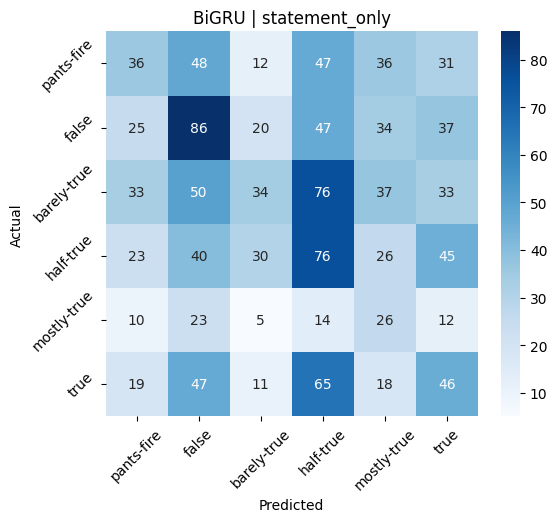


=== BiGRU | combined | TEST SET ===
Accuracy: 0.2218 | Macro-F1: 0.2119 | Weighted-F1: 0.2124
              precision    recall  f1-score   support

  pants-fire       0.21      0.31      0.25       210
       false       0.33      0.13      0.19       249
 barely-true       0.25      0.13      0.17       263
   half-true       0.24      0.36      0.29       240
 mostly-true       0.14      0.38      0.20        90
        true       0.26      0.13      0.17       206

    accuracy                           0.22      1258
   macro avg       0.24      0.24      0.21      1258
weighted avg       0.25      0.22      0.21      1258



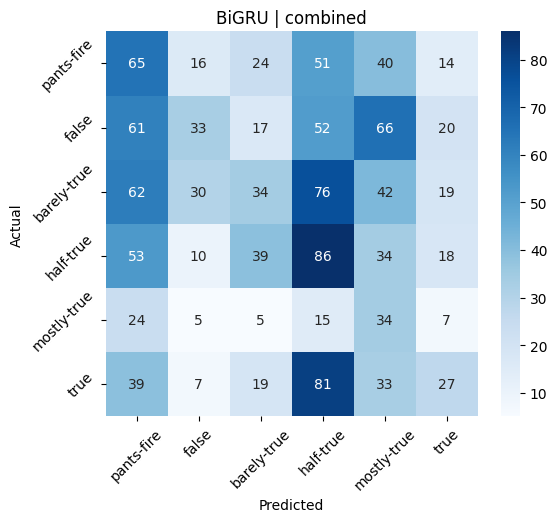

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [46]:
for exp_name, model in bi_gru_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== BiGRU | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'BiGRU | {exp_name}')

    results_table.append({
        'model': 'BiGRU', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

LSTM

In [47]:
lstm_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('LSTM', False, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'LSTM', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'LSTM | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    lstm_best[exp_name] = best_model
    print(f'--> Best LSTM config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.1652


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1546


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

LSTM | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.0774


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.1003


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.0665
--> Best LSTM config for combined: {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} (val macro-F1: 0.1003)




=== LSTM | statement_only | TEST SET ===
Accuracy: 0.2337 | Macro-F1: 0.2243 | Weighted-F1: 0.2264
              precision    recall  f1-score   support

  pants-fire       0.26      0.23      0.24       210
       false       0.26      0.18      0.21       249
 barely-true       0.30      0.24      0.26       263
   half-true       0.22      0.10      0.13       240
 mostly-true       0.13      0.33      0.19        90
        true       0.24      0.42      0.30       206

    accuracy                           0.23      1258
   macro avg       0.24      0.25      0.22      1258
weighted avg       0.25      0.23      0.23      1258



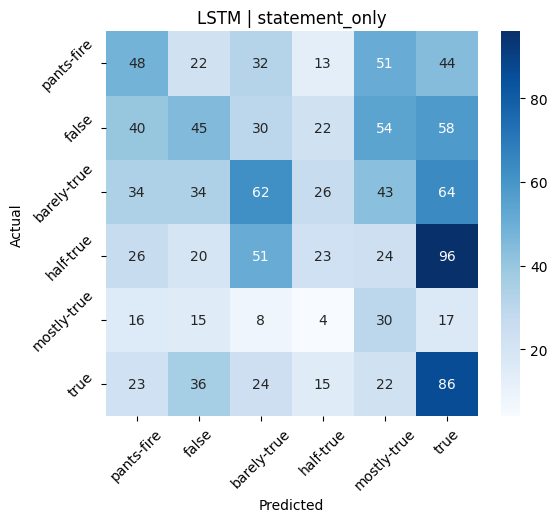


=== LSTM | combined | TEST SET ===
Accuracy: 0.1908 | Macro-F1: 0.0919 | Weighted-F1: 0.1042
              precision    recall  f1-score   support

  pants-fire       0.25      0.07      0.11       210
       false       0.13      0.04      0.06       249
 barely-true       0.26      0.04      0.07       263
   half-true       0.19      0.85      0.31       240
 mostly-true       0.00      0.00      0.00        90
        true       0.00      0.00      0.00       206

    accuracy                           0.19      1258
   macro avg       0.14      0.17      0.09      1258
weighted avg       0.16      0.19      0.10      1258



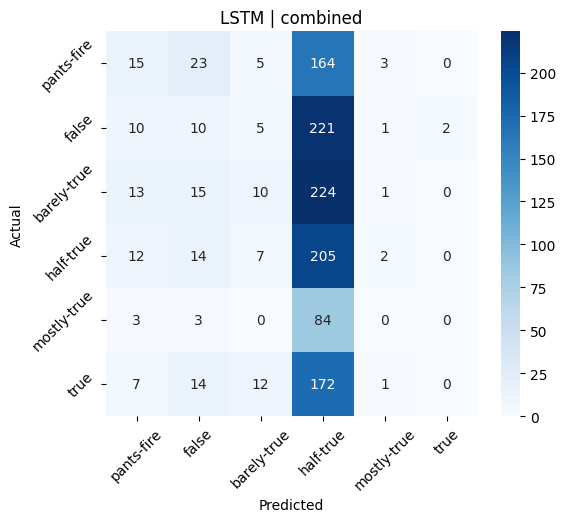

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [48]:
for exp_name, model in lstm_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== LSTM | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'LSTM | {exp_name}')

    results_table.append({
        'model': 'LSTM', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

In [49]:
bi_lstm_best = {}

for exp_name, (X_tr, X_val, X_te, emb_matrix, mlen) in experiments_seq.items():
    best_val_f1, best_model, best_cfg = -1, None, None
    vocab_size = emb_matrix.shape[0]

    for cfg in rnn_configs:
        model = build_rnn_model('LSTM', True, vocab_size, 100, emb_matrix, mlen, **cfg)
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(X_tr, y_train_cat, validation_data=(X_val, y_val_cat),
                  epochs=15, batch_size=64, class_weight=class_weights, callbacks=[es], verbose=0)

        val_preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'BiLSTM', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'BiLSTM | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg

    bi_lstm_best[exp_name] = best_model
    print(f'--> Best BiLSTM config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})\n')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiLSTM | statement_only | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2131


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiLSTM | statement_only | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.2464


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

BiLSTM | combined | {'units': 64, 'dropout': 0.2, 'learning_rate': 0.001} | val macro-F1: 0.2199


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiLSTM | combined | {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} | val macro-F1: 0.2331


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


BiLSTM | combined | {'units': 128, 'dropout': 0.4, 'learning_rate': 0.0005} | val macro-F1: 0.2064
--> Best BiLSTM config for combined: {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001} (val macro-F1: 0.2331)




=== BiLSTM | statement_only | TEST SET ===
Accuracy: 0.2321 | Macro-F1: 0.2294 | Weighted-F1: 0.2290
              precision    recall  f1-score   support

  pants-fire       0.22      0.29      0.25       210
       false       0.34      0.16      0.22       249
 barely-true       0.30      0.14      0.19       263
   half-true       0.27      0.22      0.24       240
 mostly-true       0.15      0.39      0.22        90
        true       0.21      0.32      0.26       206

    accuracy                           0.23      1258
   macro avg       0.25      0.25      0.23      1258
weighted avg       0.26      0.23      0.23      1258



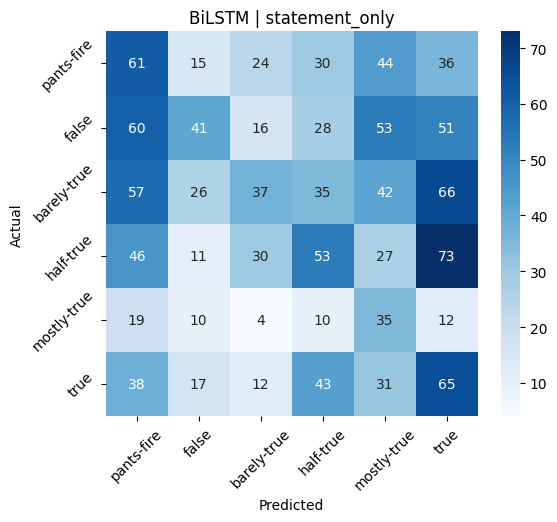


=== BiLSTM | combined | TEST SET ===
Accuracy: 0.2305 | Macro-F1: 0.2243 | Weighted-F1: 0.2246
              precision    recall  f1-score   support

  pants-fire       0.22      0.13      0.16       210
       false       0.33      0.17      0.23       249
 barely-true       0.26      0.14      0.18       263
   half-true       0.27      0.29      0.28       240
 mostly-true       0.14      0.48      0.21        90
        true       0.24      0.34      0.28       206

    accuracy                           0.23      1258
   macro avg       0.24      0.26      0.22      1258
weighted avg       0.26      0.23      0.22      1258



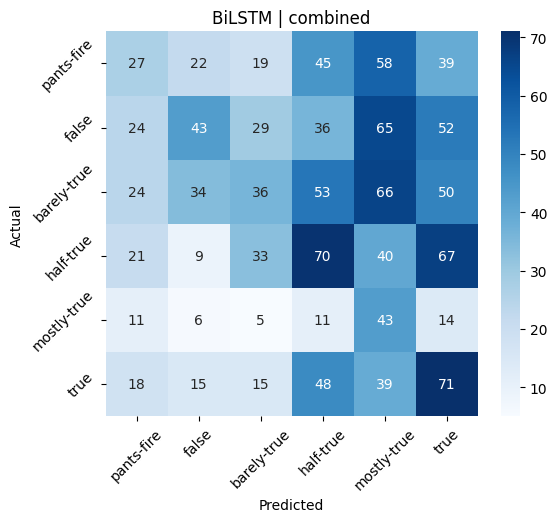

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [50]:
for exp_name, model in bi_lstm_best.items():
    X_te = experiments_seq[exp_name][2]
    preds = np.argmax(model.predict(X_te, verbose=0), axis=1)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== BiLSTM | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'BiLSTM | {exp_name}')

    results_table.append({
        'model': 'BiLSTM', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)

BERT

In [51]:
!pip install transformers -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)
# Make sure Colab Runtime > Change runtime type > GPU is selected before running this

Using device: cuda


In [52]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def bert_encode(texts, max_len):
    return bert_tokenizer(
        list(texts), max_length=max_len, padding='max_length',
        truncation=True, return_tensors='pt'
    )

BERT_MAXLEN_STMT = 64
BERT_MAXLEN_COMB = 256

bert_experiments = {
    'statement_only': {
        'train': bert_encode(train_df['statement_light'], BERT_MAXLEN_STMT),
        'val':   bert_encode(val_df['statement_light'], BERT_MAXLEN_STMT),
        'test':  bert_encode(test_df['statement_light'], BERT_MAXLEN_STMT),
    },
    'combined': {
        'train': bert_encode(train_df['combined_light'], BERT_MAXLEN_COMB),
        'val':   bert_encode(val_df['combined_light'], BERT_MAXLEN_COMB),
        'test':  bert_encode(test_df['combined_light'], BERT_MAXLEN_COMB),
    }
}
print('Tokenization done.')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenization done.


In [53]:
class LiarDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

bert_configs = [
    {'learning_rate': 5e-5, 'epochs': 2, 'batch_size': 16},
    {'learning_rate': 3e-5, 'epochs': 3, 'batch_size': 16},
    {'learning_rate': 2e-5, 'epochs': 3, 'batch_size': 32},
]

In [54]:
def evaluate_bert(model, loader):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
    return np.array(all_preds)

def run_bert_experiment(exp_name):
    enc = bert_experiments[exp_name]
    train_ds = LiarDataset(enc['train'], y_train)
    val_ds   = LiarDataset(enc['val'], y_val)
    val_loader = DataLoader(val_ds, batch_size=32)

    best_val_f1, best_model, best_cfg = -1, None, None

    for cfg in bert_configs:
        model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_classes).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['learning_rate'])
        train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True)

        model.train()
        for epoch in range(cfg['epochs']):
            total_loss = 0
            for batch in train_loader:
                optimizer.zero_grad()
                input_ids = batch['input_ids'].to(device)
                attn_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f'  epoch {epoch+1}/{cfg["epochs"]} | avg loss: {total_loss/len(train_loader):.4f}')

        val_preds = evaluate_bert(model, val_loader)
        val_f1 = f1_score(y_val, val_preds, average='macro')
        tuning_log.append({'model': 'BERT', 'experiment': exp_name, **cfg, 'val_macro_f1': val_f1})
        print(f'BERT | {exp_name} | {cfg} | val macro-F1: {val_f1:.4f}\n')

        if val_f1 > best_val_f1:
            best_val_f1, best_model, best_cfg = val_f1, model, cfg
        else:
            del model
            torch.cuda.empty_cache()

    print(f'--> Best BERT config for {exp_name}: {best_cfg} (val macro-F1: {best_val_f1:.4f})')
    return best_model

bert_best = {}
bert_best['statement_only'] = run_bert_experiment('statement_only')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/2 | avg loss: 1.7375
  epoch 2/2 | avg loss: 1.6418
BERT | statement_only | {'learning_rate': 5e-05, 'epochs': 2, 'batch_size': 16} | val macro-F1: 0.2285



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/3 | avg loss: 1.7282
  epoch 2/3 | avg loss: 1.6338
  epoch 3/3 | avg loss: 1.4029
BERT | statement_only | {'learning_rate': 3e-05, 'epochs': 3, 'batch_size': 16} | val macro-F1: 0.2438



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/3 | avg loss: 1.7349
  epoch 2/3 | avg loss: 1.6511
  epoch 3/3 | avg loss: 1.4860
BERT | statement_only | {'learning_rate': 2e-05, 'epochs': 3, 'batch_size': 32} | val macro-F1: 0.2609

--> Best BERT config for statement_only: {'learning_rate': 2e-05, 'epochs': 3, 'batch_size': 32} (val macro-F1: 0.2609)


In [55]:
bert_best['combined'] = run_bert_experiment('combined')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/2 | avg loss: 1.7655
  epoch 2/2 | avg loss: 1.7626
BERT | combined | {'learning_rate': 5e-05, 'epochs': 2, 'batch_size': 16} | val macro-F1: 0.0546



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/3 | avg loss: 1.7590
  epoch 2/3 | avg loss: 1.6987
  epoch 3/3 | avg loss: 1.5196
BERT | combined | {'learning_rate': 3e-05, 'epochs': 3, 'batch_size': 16} | val macro-F1: 0.2552



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  epoch 1/3 | avg loss: 1.7661
  epoch 2/3 | avg loss: 1.7025
  epoch 3/3 | avg loss: 1.5728
BERT | combined | {'learning_rate': 2e-05, 'epochs': 3, 'batch_size': 32} | val macro-F1: 0.2278

--> Best BERT config for combined: {'learning_rate': 3e-05, 'epochs': 3, 'batch_size': 16} (val macro-F1: 0.2552)



=== BERT | statement_only | TEST SET ===
Accuracy: 0.2711 | Macro-F1: 0.2684 | Weighted-F1: 0.2678
              precision    recall  f1-score   support

  pants-fire       0.25      0.37      0.30       210
       false       0.33      0.30      0.31       249
 barely-true       0.24      0.30      0.26       263
   half-true       0.28      0.22      0.24       240
 mostly-true       0.29      0.28      0.28        90
        true       0.29      0.17      0.21       206

    accuracy                           0.27      1258
   macro avg       0.28      0.27      0.27      1258
weighted avg       0.28      0.27      0.27      1258



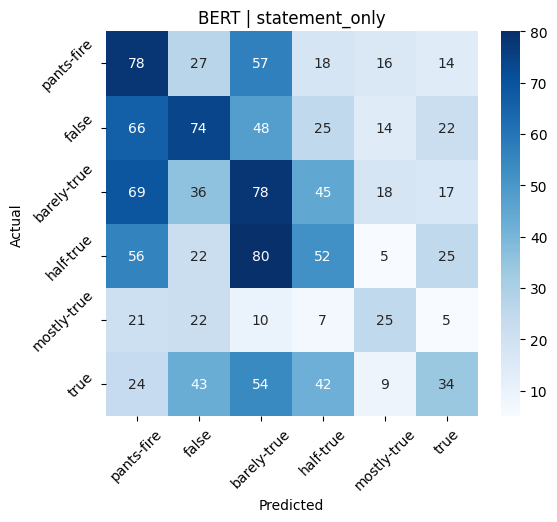


=== BERT | combined | TEST SET ===
Accuracy: 0.2695 | Macro-F1: 0.2536 | Weighted-F1: 0.2630
              precision    recall  f1-score   support

  pants-fire       0.28      0.20      0.23       210
       false       0.30      0.25      0.27       249
 barely-true       0.25      0.27      0.26       263
   half-true       0.28      0.44      0.34       240
 mostly-true       0.31      0.13      0.19        90
        true       0.24      0.23      0.23       206

    accuracy                           0.27      1258
   macro avg       0.27      0.25      0.25      1258
weighted avg       0.27      0.27      0.26      1258



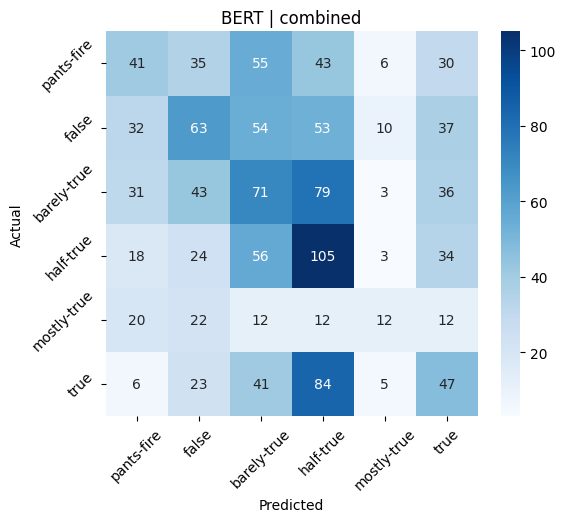

,model,experiment,representation,test_accuracy,test_macro_f1,test_weighted_f1
0,RandomForest,statement_only,tfidf,0.252782,0.247355,0.250899
1,RandomForest,combined,tfidf,0.220986,0.202150,0.218740
2,LogisticRegression,statement_only,tfidf,0.240859,0.238180,0.241790
3,LogisticRegression,combined,tfidf,0.218601,0.202809,0.213144
4,NaiveBayes,statement_only,tfidf,0.243243,0.217135,0.237521
5,NaiveBayes,combined,tfidf,0.236089,0.212081,0.227780
6,RandomForest,statement_only,word2vec,0.278219,0.240183,0.260755
7,RandomForest,combined,word2vec,0.243243,0.193665,0.220786
8,LogisticRegression,statement_only,word2vec,0.236089,0.230295,0.235967
9,LogisticRegression,combined,word2vec,0.229730,0.217379,0.230813


In [56]:
for exp_name, model in bert_best.items():
    test_ds = LiarDataset(bert_experiments[exp_name]['test'], y_test)
    test_loader = DataLoader(test_ds, batch_size=32)
    preds = evaluate_bert(model, test_loader)

    acc = accuracy_score(y_test, preds)
    f1_macro = f1_score(y_test, preds, average='macro')
    f1_weighted = f1_score(y_test, preds, average='weighted')

    print(f'\n=== BERT | {exp_name} | TEST SET ===')
    print(f'Accuracy: {acc:.4f} | Macro-F1: {f1_macro:.4f} | Weighted-F1: {f1_weighted:.4f}')
    print(classification_report(y_test, preds, target_names=label_order))

    cm = confusion_matrix(y_test, preds)
    plot_confusion(cm, f'BERT | {exp_name}')

    results_table.append({
        'model': 'BERT', 'experiment': exp_name,
        'test_accuracy': acc, 'test_macro_f1': f1_macro, 'test_weighted_f1': f1_weighted
    })

pd.DataFrame(results_table)